In [1]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [2]:
DATA_DIR = os.path.expanduser("~/pqc/PQC_Communication/Signature-Argon/results")

paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.jsonl")))
paths

['/home/momo/pqc/PQC_Communication/Signature-Argon/results/argon_keypair.jsonl',
 '/home/momo/pqc/PQC_Communication/Signature-Argon/results/argon_sign.jsonl',
 '/home/momo/pqc/PQC_Communication/Signature-Argon/results/argon_verify.jsonl',
 '/home/momo/pqc/PQC_Communication/Signature-Argon/results/argon_whole.jsonl']

In [3]:
def read_jsonl(path):
    rows = []
    bad = 0
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                bad += 1
    if bad:
        print(f"{os.path.basename(path)} : {bad} lignes JSON invalides ignorées")
    return rows

In [4]:
all_rows = []
for p in paths:
    all_rows.extend(read_jsonl(p))

df = pd.DataFrame(all_rows)
df.head()

,platform,scope,alg,op,iter,msg_len,time_us,free_mem_before,free_mem_after,mem_delta,min_free_mem_during,pk_len,sk_len,sig_len,ok
0,argon-local,local,ML_DSA_44,keypair,0,0,132214,48928,48896,32,48896,1312,2560,2420,1
1,argon-local,local,ML_DSA_44,keypair,1,0,132211,48896,48896,0,48896,1312,2560,2420,1
2,argon-local,local,ML_DSA_44,keypair,2,0,131518,48896,48896,0,48896,1312,2560,2420,1
3,argon-local,local,ML_DSA_44,keypair,3,0,130060,48896,48896,0,48896,1312,2560,2420,1
4,argon-local,local,ML_DSA_44,keypair,4,0,128394,48896,48896,0,48896,1312,2560,2420,1


In [5]:
num_cols = [
    "iter", "msg_len", "time_us",
    "free_mem_before", "free_mem_after", "mem_delta",
    "min_free_mem_during",
    "pk_len", "sk_len", "sig_len",
    "ok"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["op"] = df["op"].str.lower()
df["alg"] = df["alg"].astype(str)
df["platform"] = df["platform"].astype(str)
df["scope"] = df["scope"].astype(str)

df_ok = df[df["ok"] == 1].copy()

df_ok[["platform", "alg", "op", "time_us", "mem_delta", "min_free_mem_during"]].head()

,platform,alg,op,time_us,mem_delta,min_free_mem_during
0,argon-local,ML_DSA_44,keypair,132214,32,48896
1,argon-local,ML_DSA_44,keypair,132211,0,48896
2,argon-local,ML_DSA_44,keypair,131518,0,48896
3,argon-local,ML_DSA_44,keypair,130060,0,48896
4,argon-local,ML_DSA_44,keypair,128394,0,48896


In [6]:
df_ok["peak_mem_used"] = df_ok["free_mem_before"] - df_ok["min_free_mem_during"]
df_ok["peak_mem_used"] = df_ok["peak_mem_used"].clip(lower=0)

df_ok[["platform", "alg", "op", "free_mem_before", "min_free_mem_during", "peak_mem_used"]].head()

,platform,alg,op,free_mem_before,min_free_mem_during,peak_mem_used
0,argon-local,ML_DSA_44,keypair,48928,48896,32
1,argon-local,ML_DSA_44,keypair,48896,48896,0
2,argon-local,ML_DSA_44,keypair,48896,48896,0
3,argon-local,ML_DSA_44,keypair,48896,48896,0
4,argon-local,ML_DSA_44,keypair,48896,48896,0


In [7]:
summary = (
    df_ok.groupby(["alg", "op"])
         .agg(
             time_median_us=("time_us", "median"),
             mem_delta_mean=("mem_delta", "mean"),
             min_free_mem_mean=("min_free_mem_during", "mean"),
             peak_mem_used_mean=("peak_mem_used", "mean"),
             peak_mem_used_median=("peak_mem_used", "median")
         )
         .reset_index()
)

summary.head()

,alg,op,time_median_us,mem_delta_mean,min_free_mem_mean,peak_mem_used_mean,peak_mem_used_median
0,FALCON_512,keypair,7238279.5,1.6,50576.0,1.6,0.0
1,FALCON_512,sign,2286074.0,0.0,49816.0,0.0,0.0
2,FALCON_512,verify,36293.5,0.0,49816.0,0.0,0.0
3,FALCON_512,whole,10027706.5,1.6,49816.0,2209.6,2208.0
4,FALCON_PADDED_1024,keypair,23594174.0,1.6,48656.0,1.6,0.0


In [8]:
op_order1 = ["keypair", "sign", "verify", "whole"]

mem_table = (
    summary.pivot(index="alg", columns="op", values="peak_mem_used_median")
           .reindex(columns=op_order1)
)

mem_table

op,keypair,sign,verify,whole
alg,,,,
FALCON_512,0.0,0.0,0.0,2208.0
FALCON_PADDED_1024,0.0,NaN,NaN,NaN
ML_DSA_44,0.0,0.0,0.0,3888.0
RSA_2048_mbedTLS,0.0,0.0,0.0,0.0
SPHINCS_SHA2_128F,0.0,0.0,0.0,112.0
SPHINCS_SHA2_128S,0.0,0.0,0.0,112.0
SPHINCS_SHAKE_128F,0.0,0.0,0.0,112.0
SPHINCS_SHAKE_128S,0.0,0.0,0.0,112.0


In [9]:
op_order = ["keypair", "sign", "verify", "whole"]

time_table = (
    summary.pivot(index="alg", columns="op", values="time_median_us")
           .reindex(columns=op_order)
)

time_table

op,keypair,sign,verify,whole
alg,,,,
FALCON_512,7238279.5,2.286074e+06,36293.5,1.002771e+07
FALCON_PADDED_1024,23594174.0,NaN,NaN,NaN
ML_DSA_44,130654.5,2.272030e+05,118002.0,4.803235e+05
RSA_2048_mbedTLS,223099031.0,2.250334e+07,135904.5,3.492801e+08
SPHINCS_SHA2_128F,992167.5,2.270197e+07,1380301.5,2.505177e+07
SPHINCS_SHA2_128S,62090739.0,4.710902e+08,488195.5,5.337642e+08
SPHINCS_SHAKE_128F,4227546.5,9.918523e+07,5822894.5,1.093541e+08
SPHINCS_SHAKE_128S,278762201.5,2.069635e+09,2097920.5,2.346345e+09


In [10]:
def plot_grouped_bars(pivot_df, title, ylabel, logy=False):
    pivot_df = pivot_df.dropna(how="all")
    algos = pivot_df.index.tolist()
    ops = pivot_df.columns.tolist()

    x = np.arange(len(algos))
    width = 0.18

    plt.figure(figsize=(12, 6))
    for i, op in enumerate(ops):
        values = pivot_df[op].values
        plt.bar(x + (i - (len(ops)-1)/2) * width, values, width=width, label=op)

    plt.xticks(x, algos, rotation=45, ha="right")
    plt.xlabel("Algorithme")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title="Opération")
    if logy:
        plt.yscale("log")
    plt.tight_layout()
    plt.show()

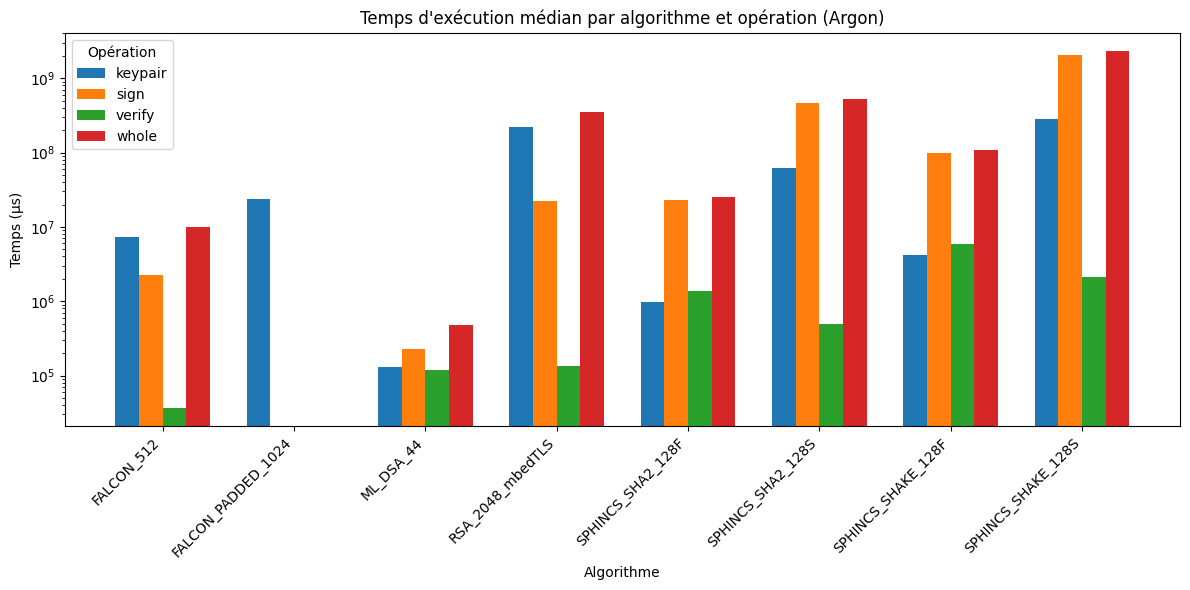

In [11]:
plot_grouped_bars(
    time_table,
    "Temps d'exécution médian par algorithme et opération (Argon)",
    "Temps (µs)",
    logy=True
)

### Analyse des performances temporelles (Argon)

La Figure ci-dessus présente les temps d’exécution médians des opérations de signature sur la plateforme **Particle Argon** pour différents algorithmes post-quantiques ainsi que RSA.

#### Observations générales

- Les temps d’exécution varient fortement selon les familles d’algorithmes.
- Les opérations `sign` et `whole` sont généralement les plus coûteuses.
- L’échelle logarithmique est nécessaire pour visualiser les écarts importants entre algorithmes.

#### Analyse par famille d’algorithmes

- **RSA-2048 (mbedTLS)** :
  - Présente les temps les plus élevés, en particulier pour les opérations de signature et `whole`.
  - Cela confirme que RSA est peu adapté aux plateformes embarquées contraintes.

- **SPHINCS+** :
  - Montre des temps de signature extrêmement élevés comparés aux autres schémas PQC.
  - Les variantes SHA2 et SHAKE présentent des comportements similaires.

- **Falcon** :
  - Offre de très bonnes performances en signature.
  - Se positionne comme l’un des algorithmes les plus rapides.

- **ML-DSA (Dilithium)** :
  - Présente un compromis intéressant entre performance et sécurité.
  - Les temps restent raisonnables comparés à SPHINCS+ et RSA.

#### Conclusion

Les résultats montrent clairement que les algorithmes basés sur les réseaux (Falcon, ML-DSA) sont les plus adaptés en termes de performance pour des environnements embarqués, contrairement à RSA et SPHINCS+ qui présentent des coûts computationnels élevés.

In [12]:
op_order = ["keypair", "sign", "verify", "whole"]

mem_table = (
    summary.pivot(index="alg", columns="op", values="peak_mem_used_median")
           .reindex(columns=op_order)
)

mem_table

op,keypair,sign,verify,whole
alg,,,,
FALCON_512,0.0,0.0,0.0,2208.0
FALCON_PADDED_1024,0.0,NaN,NaN,NaN
ML_DSA_44,0.0,0.0,0.0,3888.0
RSA_2048_mbedTLS,0.0,0.0,0.0,0.0
SPHINCS_SHA2_128F,0.0,0.0,0.0,112.0
SPHINCS_SHA2_128S,0.0,0.0,0.0,112.0
SPHINCS_SHAKE_128F,0.0,0.0,0.0,112.0
SPHINCS_SHAKE_128S,0.0,0.0,0.0,112.0


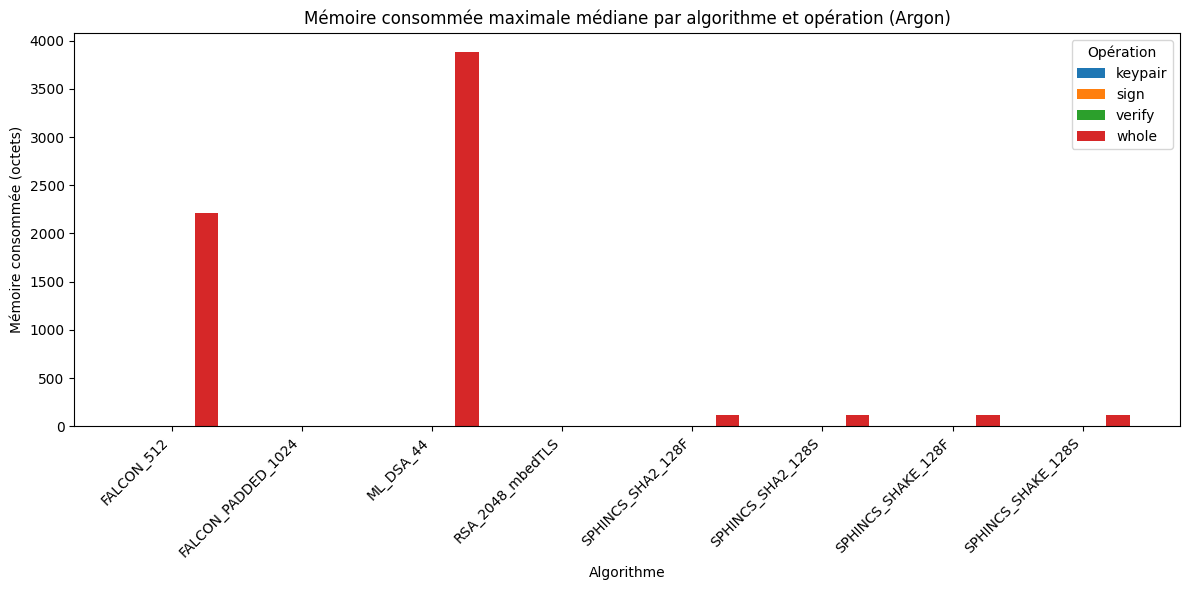

In [13]:
plot_grouped_bars(
    mem_table,
    "Mémoire consommée maximale médiane par algorithme et opération (Argon)",
    "Mémoire consommée (octets)",
    logy=False
)

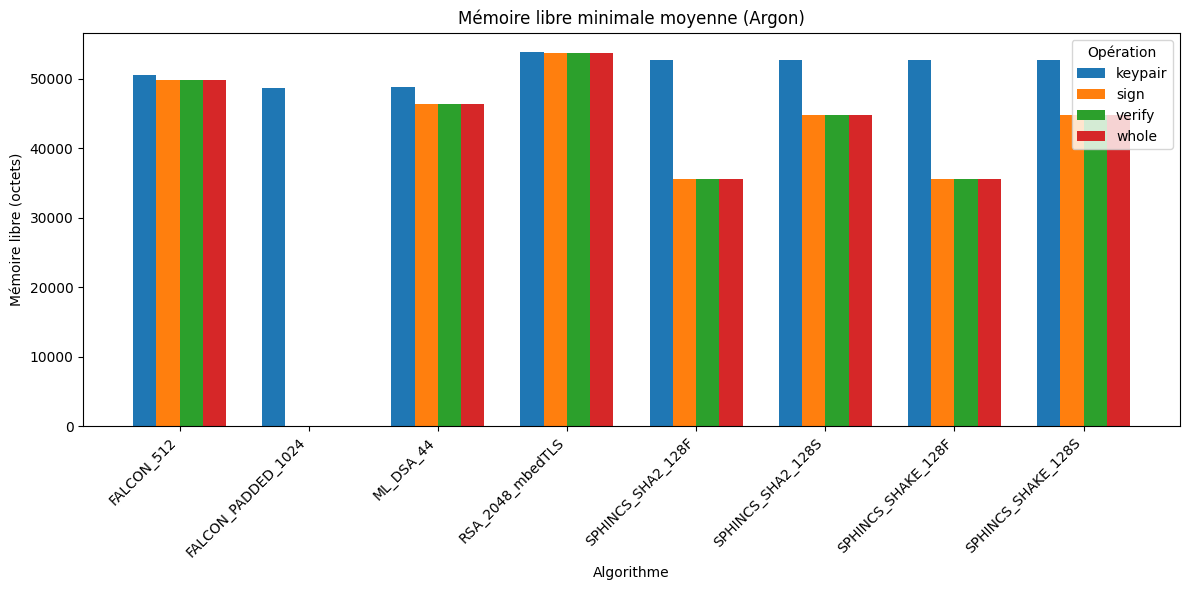

In [14]:
min_free_table = (
    summary.pivot(index="alg", columns="op", values="min_free_mem_mean")
           .reindex(columns=op_order)
)

plot_grouped_bars(
    min_free_table,
    "Mémoire libre minimale moyenne (Argon)",
    "Mémoire libre (octets)",
    logy=False
)

### Analyse de la consommation mémoire (Argon)

Les figures ci-dessus présentent deux indicateurs complémentaires de la mémoire sur la plateforme Argon :

- Mémoire libre minimale
- Mémoire consommée maximale (pic)

#### Mémoire libre minimale

- La mémoire libre reste globalement stable pour chaque algorithme.
- Les différences observées reflètent principalement l’empreinte mémoire globale de l’algorithme.
- Les algorithmes comme **RSA** et **Falcon** laissent plus de mémoire libre que **SPHINCS+**.

#### Mémoire consommée maximale

- Cette métrique correspond à la baisse maximale de mémoire libre pendant l’exécution.
- Elle permet d’estimer la consommation mémoire dynamique réelle.

Observations :

- **ML-DSA (Dilithium)** :
  - Présente le pic mémoire le plus élevé (~3.9 KB).
- **Falcon** :
  - Consommation intermédiaire (~2.2 KB).
- **SPHINCS+** :
  - Consommation très faible (~100–150 bytes).
- **RSA** :
  - Consommation faible, mais fortement dominée par son coût temporel.

#### Interprétation

- Les opérations isolées (`keypair`, `sign`, `verify`) présentent souvent une variation mémoire faible ou nulle.
- Cela s’explique par l’utilisation d’allocations statiques ou persistantes.
- L’opération `whole` révèle mieux les pics mémoire car elle enchaîne plusieurs primitives.

#### Conclusion

La consommation mémoire sur Argon reste globalement maîtrisée pour tous les algorithmes. Cependant, ML-DSA et Falcon présentent une pression mémoire plus élevée que SPHINCS+, qui est très léger mais beaucoup plus lent en temps d’exécution.

Ainsi, le choix d’un algorithme dépend du compromis entre :
- performance temporelle
- consommation mémoire
- contraintes de la plateforme

In [15]:
import pandas as pd
import json

rows = []
bad_lines = []

with open("energy/argon_energy.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        s = line.strip()
        
        # ignorer les lignes vides
        if not s:
            continue
        
        # garder seulement les lignes qui ressemblent à du JSON objet
        if not (s.startswith("{") and s.endswith("}")):
            bad_lines.append((i, s[:200]))
            continue
        
        try:
            rows.append(json.loads(s))
        except json.JSONDecodeError:
            bad_lines.append((i, s[:200]))

df_energy = pd.DataFrame(rows)

print("JSON valides :", len(df_energy))
print("Lignes ignorées :", len(bad_lines))

df_energy.head()

JSON valides : 29
Lignes ignorées : 0


,platform,alg,op,iters,duration_s,time_per_op_s,baseline_mean_ua,run_mean_ua_raw,run_mean_ua_corrected,energy_j,energy_per_op_j,timestamp,energy_status,pk_len,sk_len,sig_len,msg_len,last_ok
0,argon-local,ML_DSA_44,keypair,20,5.186718,0.259336,35916.009535,52612.570133,16696.560599,0.285781,0.014289,2026-04-08T14:59:25,usable,NaN,NaN,NaN,NaN,NaN
1,argon-local,ML_DSA_44,sign,20,7.237722,0.361886,35353.209945,52554.042962,17200.833017,0.410833,0.020542,2026-04-08T15:01:38,usable,NaN,NaN,NaN,NaN,NaN
2,argon-local,ML_DSA_44,verify,20,4.150488,0.207524,35844.579730,53718.602737,17874.023007,0.244814,0.012241,2026-04-08T15:03:13,usable,NaN,NaN,NaN,NaN,NaN
3,argon-local,ML_DSA_44,whole,20,13.590051,0.679503,35969.459965,53056.040341,17086.580376,0.766285,0.038314,2026-04-08T15:04:47,usable,NaN,NaN,NaN,NaN,NaN
4,argon-local,SPHINCS_SHA2_128F,keypair,20,22.484435,1.124222,35267.167396,52649.443265,17382.275869,1.289741,0.064487,2026-04-08T19:27:10,usable,NaN,NaN,NaN,NaN,NaN


In [16]:
df_energy = df_energy.drop_duplicates()

if "iters" not in df_energy.columns:
    if "argon_jsonl_count" in df_energy.columns:
        df_energy["iters"] = df_energy["argon_jsonl_count"]
    else:
        df_energy["iters"] = 1

if "time_per_op_s" not in df_energy.columns:
    df_energy["time_per_op_s"] = df_energy["duration_s"] / df_energy["iters"]

if "energy_per_op_j" not in df_energy.columns:
    df_energy["energy_per_op_j"] = df_energy["energy_j"] / df_energy["iters"]

df_energy["time_per_op_ms"] = df_energy["time_per_op_s"] * 1000
df_energy["energy_per_op_mj"] = df_energy["energy_per_op_j"] * 1000

df_energy.head()

,platform,alg,op,iters,duration_s,time_per_op_s,baseline_mean_ua,run_mean_ua_raw,run_mean_ua_corrected,energy_j,energy_per_op_j,timestamp,energy_status,pk_len,sk_len,sig_len,msg_len,last_ok,time_per_op_ms,energy_per_op_mj
0,argon-local,ML_DSA_44,keypair,20,5.186718,0.259336,35916.009535,52612.570133,16696.560599,0.285781,0.014289,2026-04-08T14:59:25,usable,NaN,NaN,NaN,NaN,NaN,259.335899,14.289058
1,argon-local,ML_DSA_44,sign,20,7.237722,0.361886,35353.209945,52554.042962,17200.833017,0.410833,0.020542,2026-04-08T15:01:38,usable,NaN,NaN,NaN,NaN,NaN,361.886120,20.541651
2,argon-local,ML_DSA_44,verify,20,4.150488,0.207524,35844.579730,53718.602737,17874.023007,0.244814,0.012241,2026-04-08T15:03:13,usable,NaN,NaN,NaN,NaN,NaN,207.524383,12.240675
3,argon-local,ML_DSA_44,whole,20,13.590051,0.679503,35969.459965,53056.040341,17086.580376,0.766285,0.038314,2026-04-08T15:04:47,usable,NaN,NaN,NaN,NaN,NaN,679.502535,38.314236
4,argon-local,SPHINCS_SHA2_128F,keypair,20,22.484435,1.124222,35267.167396,52649.443265,17382.275869,1.289741,0.064487,2026-04-08T19:27:10,usable,NaN,NaN,NaN,NaN,NaN,1124.221742,64.487057


In [17]:
summary = df_energy.groupby(["alg","op"]).mean(numeric_only=True)
summary

iters   duration_s  time_per_op_s  baseline_mean_ua  run_mean_ua_raw  \
alg                op                                                                              
FALCON_512         keypair   20.0   203.075600      10.153780      35460.609287     53033.255585   
                   sign      20.0    47.156892       2.357845      35598.905095     52429.934448   
                   verify    20.0     2.501800       0.125090      35626.593670     52571.088330   
                   whole     20.0   235.966185      11.798309     111340.293188    157790.521197   
FALCON_PADDED_1024 keypair   20.0     3.016191       0.150810     110429.237740    161283.601781   
ML_DSA_44          keypair   20.0     5.186718       0.259336      35916.009535     52612.570133   
                   sign      20.0     7.237722       0.361886      35353.209945     52554.042962   
                   verify    20.0     4.150488       0.207524      35844.579730     53718.602737   
                   whole     20.0    13.590051       0.679503      35969.459965     53056.040341   
RSA_2048_mbedTLS   keypair    2.0   345.632171     172.816085      35427.766473     52184.525159   
                   sign      20.0   450.141191      22.507060     108606.928700    150918.293129   
                   verify    20.0     3.192696       0.159635     105132.054437    156158.588402   
                   whole      5.0  1401.865265     280.373053     103466.897235    149837.499832   
SPHINCS_SHA2_128F  keypair   20.0    22.484435       1.124222      35267.167396     52649.443265   
                   sign       5.0   115.105024      23.021005      35788.068353     54906.519276   
                   verify     5.0     8.609955       1.721991      35617.168727     54090.407319   
                   whole      4.0   102.131436      25.532859     110724.989957    158854.124218   
SPHINCS_SHA2_128S  keypair    2.0   126.023561      63.011781      36771.738584     56950.643635   
                   sign       2.0   951.482578     475.741289      35469.015699     51616.299288   
                   verify     5.0     3.995029       0.799006      35244.064852     52057.889543   
                   whole      1.0   549.416368     549.416368      35209.332513     55914.610802   
SPHINCS_SHAKE_128F keypair   10.0    46.187103       4.618710      35523.768522     53465.612118   
                   sign      10.0   996.279423      99.627942      35304.240638     53580.248654   
                   verify    10.0    60.443054       6.044305      36041.880160     53398.183403   
                   whole      5.0   568.166634     113.633327      35641.630850     51859.303442   
SPHINCS_SHAKE_128S keypair    2.0   545.141928     272.570964      35648.351315     55623.298512   
                   sign       1.0  2134.594561    2134.594561      35788.810944     52137.395439   
                   verify    20.0    43.784979       2.189249      35320.407501     51337.655065   
                   whole      1.0  2418.101577    2418.101577      35493.506212     52740.844625   

                            run_mean_ua_corrected    energy_j  energy_per_op_j  pk_len  sk_len  sig_len  msg_len  \
alg                op                                                                                              
FALCON_512         keypair           17572.646298   11.776300         0.588815     NaN     NaN      NaN      NaN   
                   sign              16831.029353    2.619207         0.130960     NaN     NaN      NaN      NaN   
                   verify            16944.494660    0.139893         0.006995     NaN     NaN      NaN      NaN   
                   whole             46450.228010   36.170254         1.808513     NaN     NaN      NaN      NaN   
FALCON_PADDED_1024 keypair           50854.364041    0.506175         0.025309     NaN     NaN      NaN      NaN   
ML_DSA_44          keypair           16696.560599    0.285781         0.014289     NaN     NaN      NaN      NaN   

In [18]:
pivot_energy = df_energy.pivot(
    index="alg",
    columns="op",
    values="energy_per_op_mj"
)

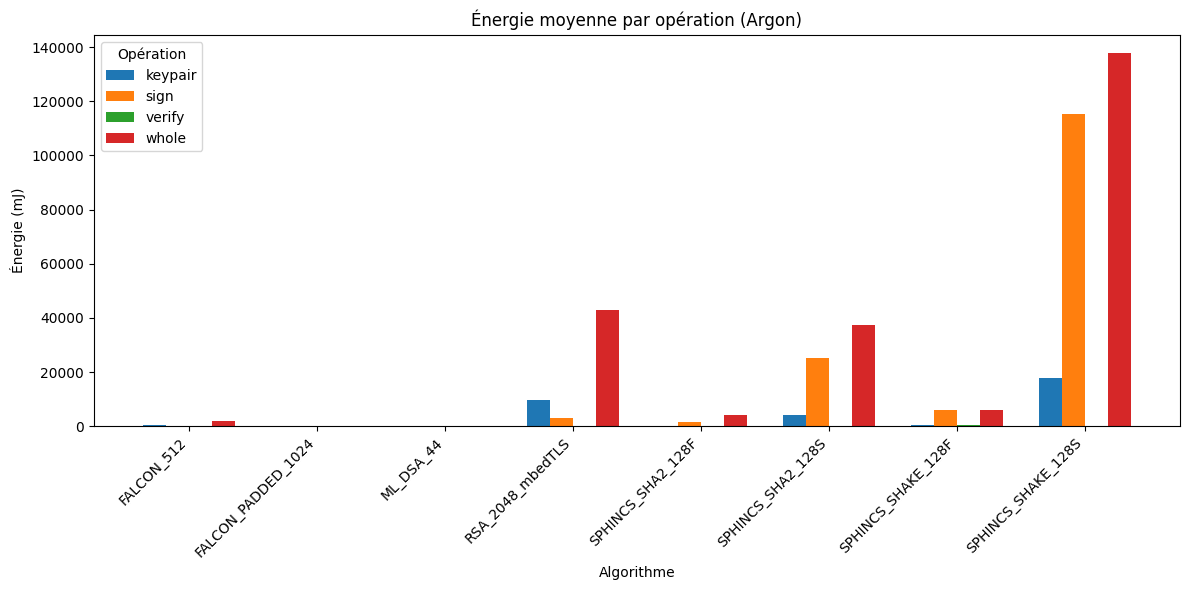

In [19]:
plot_grouped_bars(
    pivot_energy,
    "Énergie moyenne par opération (Argon)",
    "Énergie (mJ)",
    logy=False
)